# Übertragungsfunktion: Real- und Imaginärteil

Dieses Notebook zerlegt eine gegebene Übertragungsfunktion $G(s)$ in Real- und Imaginärteil, indem $s = i\omega$ substituiert wird.

$$G(i\omega) = \mathrm{Re}\{G(i\omega)\} + i \cdot \mathrm{Im}\{G(i\omega)\}$$

Passe einfach die Definition von `G_s` in der Zelle unten an deine eigene Übertragungsfunktion an. Alle weiteren Schritte (Rationalisierung, Real-/Imaginärteil, Wertetabelle, Ortskurve) werden automatisch nachgezogen.

In [12]:
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Math

sp.init_printing()

# Symbole definieren
s = sp.symbols('s')
w = sp.symbols('omega', real=True)   # omega ist reell -> wichtig für re()/im()

# Weitere Parameter der Übertragungsfunktion (bei Bedarf ergänzen/anpassen)
K = sp.symbols('K', positive=True, real=True)

## Schritt 1: Übertragungsfunktion G(s) definieren

Beispiel: ein PT2-Glied. Einfach durch die eigene Funktion ersetzen.

In [13]:
# Beispiel-Übertragungsfunktion -- hier anpassen:
G_s = (2)/((s**3+2.3*s**2+8/5*s+2))

print('G(s) =')
display(G_s)

G(s) =


## Schritt 2: Substitution s = i·ω (Zwischenschritt, noch unvereinfacht)

In [14]:
G_jw_roh = G_s.subs(s, sp.I*w)

print('G(i\u03c9) nach Substitution (vor Vereinfachung) =')
display(G_jw_roh)

G(iω) nach Substitution (vor Vereinfachung) =


## Schritt 3: Rationalisierung (Erweitern mit konjugiert komplexem Nenner)

Um Real- und Imaginärteil sauber trennen zu können, wird der Ausdruck zunächst auf einen gemeinsamen Nenner gebracht und mit dem konjugiert Komplexen des Nenners erweitert. Das macht `sympy` intern über `re()`/`im()` automatisch, hier zur Nachvollziehbarkeit zusätzlich explizit ausgegeben.

In [15]:
G_jw_zusammengefasst = sp.together(G_jw_roh)
Zaehler, Nenner = sp.fraction(G_jw_zusammengefasst)
Nenner_konjugiert = sp.conjugate(Nenner)

Zaehler_erweitert = sp.expand(Zaehler * Nenner_konjugiert)
Nenner_erweitert = sp.simplify(sp.expand(Nenner * Nenner_konjugiert))

print('Zähler nach Erweitern mit konjugiert komplexem Nenner =')
display(Zaehler_erweitert)

print('Nenner nach Erweitern (reell) =')
display(Nenner_erweitert)

Zähler nach Erweitern mit konjugiert komplexem Nenner =


Nenner nach Erweitern (reell) =


## Schritt 4: Real- und Imaginärteil bestimmen

In [16]:
Re_G = sp.simplify(sp.re(G_jw_roh))
Im_G = sp.simplify(sp.im(G_jw_roh))

display(Math(r'\mathrm{Re}\{G(i\omega)\} = ' + sp.latex(Re_G)))
display(Math(r'\mathrm{Im}\{G(i\omega)\} = ' + sp.latex(Im_G)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Schritt 5: Betrag und Phase (aus Re/Im)

In [17]:
Betrag_G = sp.simplify(sp.sqrt(Re_G**2 + Im_G**2))
Phase_G = sp.simplify(sp.atan2(Im_G, Re_G))

display(Math(r'|G(i\omega)| = ' + sp.latex(Betrag_G)))
display(Math(r'\varphi(\omega) = ' + sp.latex(Phase_G)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Schritt 6: Wertetabelle für verschiedene ω

Parameterwerte einsetzen und für eine Liste von ω-Werten auswerten. Frequenzbereich und Parameter bei Bedarf anpassen.

In [18]:
# Numerische Parameterwerte -- an eigene Übertragungsfunktion anpassen:
werte = {}

Re_num = sp.lambdify(w, Re_G.subs(werte), 'numpy')
Im_num = sp.lambdify(w, Im_G.subs(werte), 'numpy')
Betrag_num = sp.lambdify(w, Betrag_G.subs(werte), 'numpy')
Phase_num = sp.lambdify(w, Phase_G.subs(werte), 'numpy')

# ω-Stützstellen -- Anzahl/Bereich bei Bedarf anpassen:
omega_werte = np.array([0, 0.1, 1,2,3,4,5, 10,20,30,40,50,60,70,80,90,100])

tabelle = pd.DataFrame({
    'omega [rad/s]': omega_werte,
    'Re': Re_num(omega_werte),
    'Im': Im_num(omega_werte),
    'Betrag': Betrag_num(omega_werte),
    'Phase [rad]': Phase_num(omega_werte),
    'Phase [deg]': np.degrees(Phase_num(omega_werte)),
})

tabelle

,omega [rad/s],Re,Im,Betrag,Phase [rad],Phase [deg]
0,0.0,1.000000e+00,-0.000000,1.000000,-0.000000,-0.000000
1,0.1,1.005132e+00,-0.080838,1.008378,-0.080252,-4.598110
2,1.0,-1.333333e+00,-2.666667,2.981424,-2.034444,-116.565051
3,2.0,-1.923077e-01,0.128205,0.231125,2.553590,146.309932
4,3.0,-4.439011e-02,0.052698,0.068903,2.270828,130.108854
5,4.0,-1.536831e-02,0.025437,0.029719,2.114274,121.138972
6,5.0,-6.619258e-03,0.013954,0.015444,2.013722,115.377744
7,10.0,-4.469537e-04,0.001929,0.001980,1.798486,103.045637
8,20.0,-2.853956e-05,0.000248,0.000249,1.685501,96.572119
9,30.0,-5.660427e-06,0.000074,0.000074,1.647375,94.387651


## Schritt 7: Ortskurve

Real- und Imaginärteil aus der Wertetabelle als Ortskurve (Nyquist-Diagramm) darstellen. Zusätzlich wird eine feiner aufgelöste Kurve im Hintergrund geplottet, damit der Verlauf zwischen den Stützstellen sichtbar ist.

C:\Users\morte\AppData\Local\Temp\ipykernel_29644\3534619337.py:1: RuntimeWarning: divide by zero encountered in log10
  omega_fein = np.logspace(np.log10(omega_werte.min()), np.log10(omega_werte.max()), 500)
c:\Users\morte\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\function_base.py:163: RuntimeWarning: invalid value encountered in multiply
  y *= step
c:\Users\morte\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\function_base.py:173: RuntimeWarning: invalid value encountered in add
  y += start


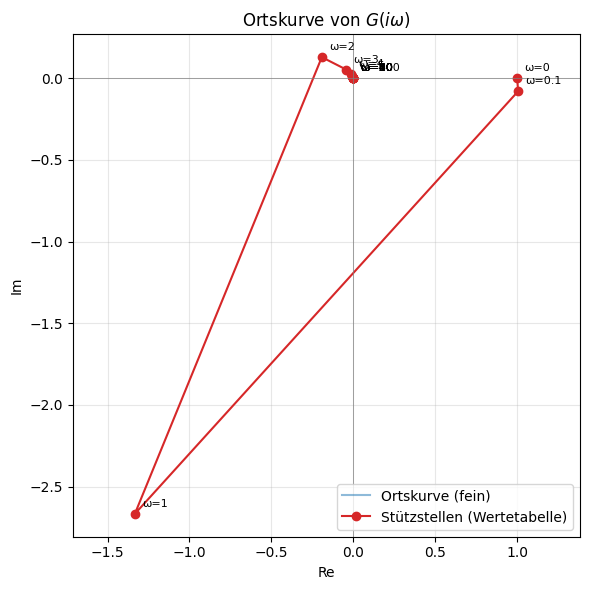

In [19]:
omega_fein = np.logspace(np.log10(omega_werte.min()), np.log10(omega_werte.max()), 500)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(Re_num(omega_fein), Im_num(omega_fein), '-', color='tab:blue', alpha=0.5, label='Ortskurve (fein)')
ax.plot(tabelle['Re'], tabelle['Im'], 'o-', color='tab:red', label='Stützstellen (Wertetabelle)')

for _, zeile in tabelle.iterrows():
    ax.annotate(f"\u03c9={zeile['omega [rad/s]']:g}", (zeile['Re'], zeile['Im']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_title('Ortskurve von $G(i\\omega)$')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')
ax.legend()

plt.tight_layout()
plt.show()

## Bonus: Real- und Imaginärteil über ω geplottet

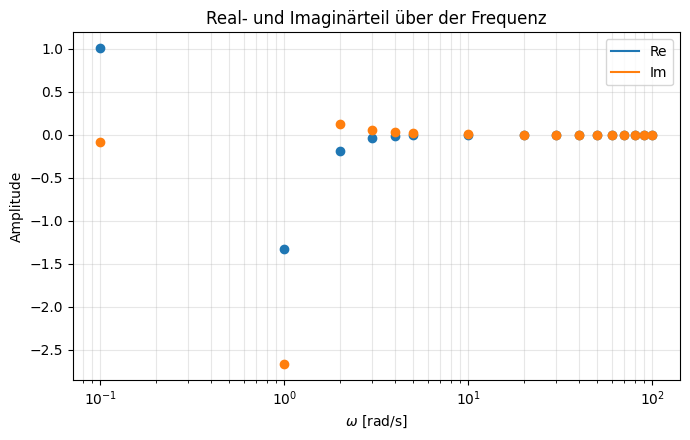

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(omega_fein, Re_num(omega_fein), label='Re')
ax.plot(omega_fein, Im_num(omega_fein), label='Im')
ax.plot(tabelle['omega [rad/s]'], tabelle['Re'], 'o', color='tab:blue')
ax.plot(tabelle['omega [rad/s]'], tabelle['Im'], 'o', color='tab:orange')
ax.set_xscale('log')
ax.set_xlabel(r'$\omega$ [rad/s]')
ax.set_ylabel('Amplitude')
ax.set_title('Real- und Imaginärteil über der Frequenz')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()